## Visualization Using Dimensionality Reduction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.preprocessing import LabelEncoder

In [ ]:
data = pd.read_csv("/workspaces/group-project-bas-team/data/cleaned_data.csv")

In [6]:
# Splitting data into training and test sets
data['order_year'].unique()

# Years 2018-2021 will be our test data
# Years 2022-2023 will be our train data

train = data[data['order_year']<=2021]
test = data[data['order_year']>2021]

In [7]:
# to start, we will try using Category as our target
# this best simulates our end goal of enhancing product recommendation
# we are hoping to be able to use demographics and previous purchases to identify what products to recommend
# Since title and ASIN/ISBN directly determine the category, we will create a subset of the data that does not include these features
data_limited_train = train.drop(['Title', 'ASIN/ISBN (Product Code)'], axis=1)
data_limited_test = test.drop(['Title', 'ASIN/ISBN (Product Code)'], axis=1)

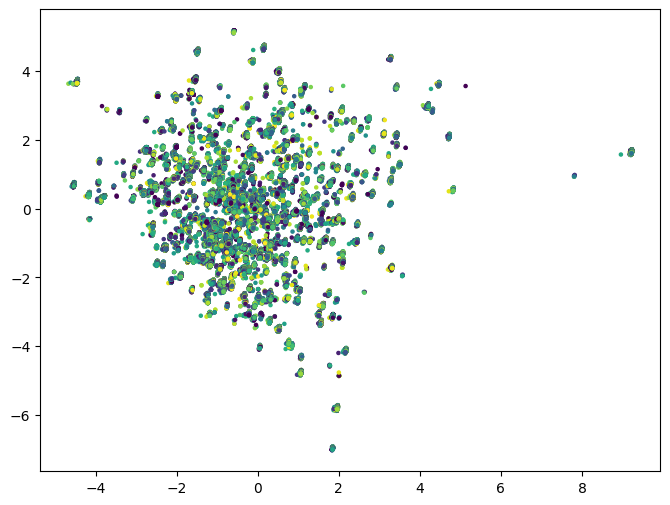

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_train = data_limited_train.drop('Category', axis=1)
y_train = data_limited_train['Category']
X_train_scaled = StandardScaler().fit_transform(X_train)

X_test = data_limited_test.drop('Category', axis=1)
y_test = data_limited_test['Category']
X_test_scaled = StandardScaler().fit_transform(X_test)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

#We'll need to figure out what plots to use as well as what specific columns we want to target

#Gets visualization plot started
plt.figure(figsize=(8, 6))
#Insert plot of choice here
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, s=5)
plt.show()

Variance Explained per Principal Component: [0.02583405 0.05018351 0.07369174 0.09544504 0.11389543 0.13202384
 0.14980748 0.16686028 0.18359016 0.20025496 0.21663496 0.23277663
 0.24874186 0.26433242 0.27942152 0.29425414 0.30888915 0.32345554
 0.33786841 0.35220231 0.36646378 0.38050143 0.3944626  0.40823671
 0.42187044 0.43539363 0.44883805 0.4622197  0.47550629 0.4887134
 0.50171119 0.51461823 0.52749906 0.54029546 0.55300938 0.56562318
 0.57794655 0.58999202 0.60168428 0.6131666  0.6240985  0.63477901
 0.64481983 0.65416528 0.66338345 0.6723406  0.68117754 0.68953683
 0.69764205 0.7055705  0.713346   0.72064944 0.72786526 0.7348711
 0.74183753 0.74870965 0.75553505 0.76228154 0.76897987 0.77563074
 0.78225158 0.78884634 0.79542031 0.80198593 0.80853547 0.8150638
 0.82156436 0.82803041 0.83446011 0.84084711 0.84715339 0.85340621
 0.85958026 0.86563392 0.87156641 0.87745627 0.88311067 0.88868483
 0.89397063 0.89917156 0.90419849 0.90919161 0.91406851 0.91862826
 0.92312008 0.9274389

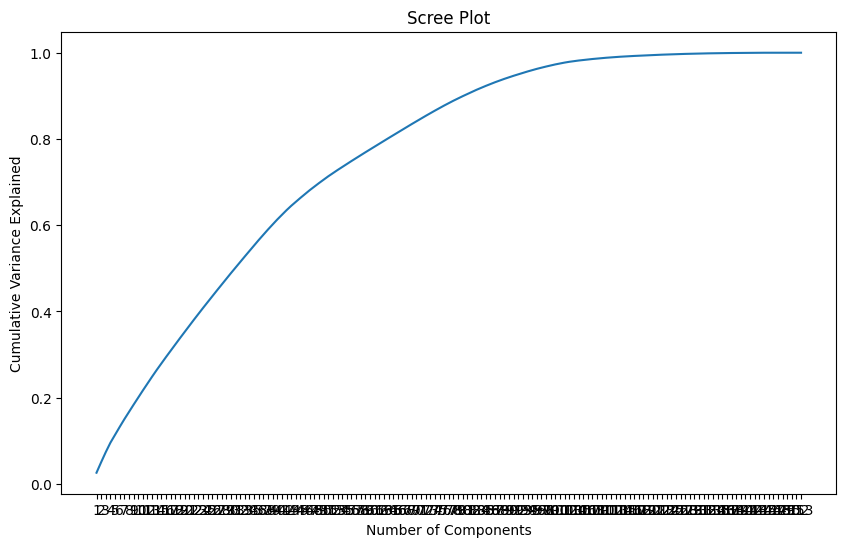

In [9]:
pca_scree = PCA()
X_pca_scree = pca_scree.fit_transform(X_train_scaled)

variance_explained = pca_scree.explained_variance_ratio_
print("Variance Explained per Principal Component:", variance_explained.cumsum())

# Step 4: Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variance_explained) + 1), variance_explained.cumsum())
plt.xticks(range(1, len(variance_explained) + 1))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Scree Plot")
plt.show()

In [10]:
import numpy as np

threshold = 0.95
n_components = np.argmax(variance_explained.cumsum() >= threshold) + 1
print(f"Number of components for {threshold*100}% variance: {n_components}")

Number of components for 95.0% variance: 93


In [11]:
# Performing PCA with 93 components
pca = PCA(n_components=93)
X_train_reduced = pca.fit_transform(X_train_scaled)
X_test_reduced = pca.fit_transform(X_test_scaled)

In [ ]:
# Accuracy of reduced data

knn = KNeighborsClassifier()
knn.fit(X_train_reduced, y_train)
pred = knn.predict(X_test_reduced)

accuracy_score(y_test, pred)

In [ ]:
# %pip install factor_analyzer

Constant columns: RangeIndex(start=88, stop=89, step=1)


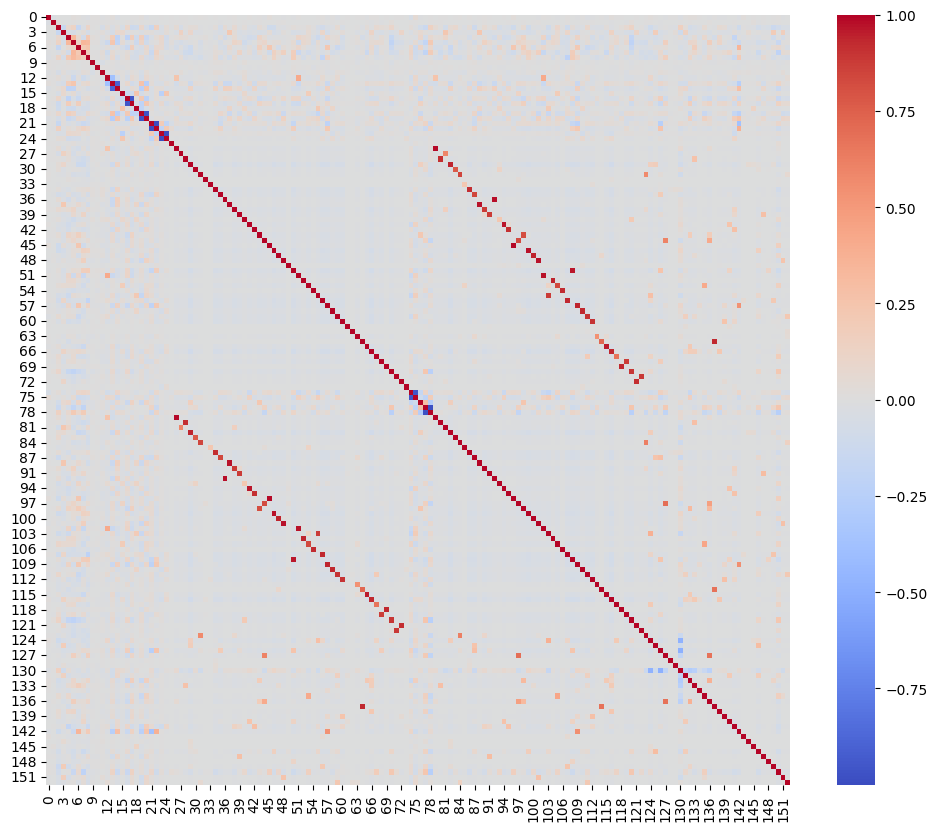

/usr/local/python/3.12.1/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


KMO Model: 0.09070150848275949


In [ ]:
from factor_analyzer.factor_analyzer import calculate_kmo

df = pd.DataFrame(X_train_scaled)

constant_columns = df.columns[df.nunique() <= 1]
print(f"Constant columns: {constant_columns}")

# Drop constant columns if any
df = df.drop(columns=constant_columns)

# Correlation analysis
corr_matrix = df.corr()

# Plotting the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.show()

kmo_all, kmo_model = calculate_kmo(df)

print(f"KMO Model: {kmo_model}") 
# KMO < 0.6 --> our data is not suitable for factor analysis

In [ ]:
# UMAP

#!pip install numpy==1.24
#!pip install umap-learn
#!pip install matplotlib
#!pip install pandas

In [3]:
import pandas as pd

In [4]:
data = pd.read_csv('/workspaces/group-project-bas-team/data/cleaned_data.csv')

train = data[data['order_year']<=2021]
test = data[data['order_year']>2021]

data_limited_train = train.drop(['Title', 'ASIN/ISBN (Product Code)'], axis=1)
data_limited_test = test.drop(['Title', 'ASIN/ISBN (Product Code)'], axis=1)

In [5]:
from sklearn.preprocessing import StandardScaler

X_train = data_limited_train.drop('Category', axis=1)
y_train = data_limited_train['Category']
X_train_scaled = StandardScaler().fit_transform(X_train)

X_test = data_limited_test.drop('Category', axis=1)
y_test = data_limited_test['Category']
X_test_scaled = StandardScaler().fit_transform(X_test)

In [6]:
import umap

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_train_scaled)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/python/3.12.1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


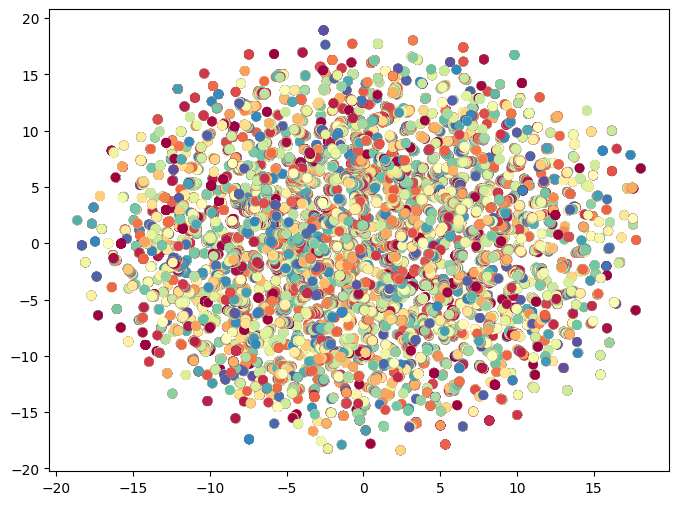

In [7]:
import matplotlib.pyplot as plt

#Gets visualization plot started
plt.figure(figsize=(8, 6))
#Insert plot of choice here
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_train, cmap=plt.cm.Spectral)
plt.show()

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Accuracy of original data
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)

accuracy_score(y_test, pred)

0.033847501786908304

In [12]:
import umap

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_train_umap = umap_model.fit_transform(X_train_scaled)
X_test_umap = umap_model.fit_transform(X_test_scaled)

/usr/local/python/3.12.1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train_umap, y_train)
pred = knn.predict(X_test_umap)

accuracy_score(y_test, pred)
# less accurate than PCA
# either stick with PCA or edit hyperparameters to improve UMAP

0.009637776394364899